## Plot fraction of individuals with low neutralization titers by strain

In [1]:
# Import packages
import itertools
import os
import altair as alt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gmean
from IPython.display import IFrame
from scipy.stats import mannwhitneyu
import statsmodels.stats.multitest


# Ignore error message from Altair about large dataframes
_ = alt.data_transformers.disable_max_rows()

# Basic color palette
color_palette = [
    '#345995', #blue
    '#03cea4', #teal
    '#ca1551', #red
    '#eac435', #yellow
               ]

In [2]:
# Define inputs
resultsdir = '../results'
os.makedirs(resultsdir, exist_ok = True)

# Define titers
titers = pd.read_csv(
    '../../../results/aggregated_titers/titers_EllebedyVaccineCohort.csv'
)

titers = titers.replace({'mRNA_': 'mRNA-1010_'})
titers['serum_new'] = titers['serum'].str.replace('mRNA_', 'mRNA-1010_', regex=False)
titers = titers.drop('serum', axis=1).rename(columns={'serum_new': 'serum'})


titers = titers.assign(
    vaccine = lambda x: x['serum'].str.split('_').str[0],
    participant = lambda x: x['serum'].str.split('_').str[1],
    timepoint = lambda x: x['serum'].str.split('_').str[2],
    subtype = lambda x: x['virus'].str.split('_').str[-1]
)

# Add another timepoint that includes 121 and 181 in teh same row
# Filter rows where timepoint is 121 or 181
late_tp_df = titers[titers['timepoint'].isin(['d121', 'd181'])].copy()
# Set new combined timepoint value
late_tp_df['timepoint'] = 'd121 or d181'
# Append to original DataFrame
titers = pd.concat([titers, late_tp_df], ignore_index=True)

# Calculate number of unique participants per vaccine
n_participants = titers.groupby('vaccine')['participant'].nunique()

# Create a mapping dictionary
vaccine_pretty = {v: f"{v} (n={n_participants[v]})" for v in n_participants.index}

# Map to a new pretty column
titers['vaccine_pretty'] = titers['vaccine'].map(vaccine_pretty)
titers['vaccine'] = titers['vaccine'].map(vaccine_pretty)

titers.serum.unique()

array(['Fluarix_397-001_d0', 'Fluarix_397-001_d181',
       'Fluarix_397-001_d29', 'Fluarix_397-002_d0',
       'Fluarix_397-002_d181', 'Fluarix_397-002_d29',
       'Fluarix_397-005_d0', 'Fluarix_397-005_d181',
       'Fluarix_397-005_d29', 'Fluarix_397-007_d0',
       'Fluarix_397-007_d121', 'Fluarix_397-007_d29',
       'Fluarix_397-009_d0', 'Fluarix_397-009_d121',
       'Fluarix_397-009_d29', 'Fluarix_397-011_d0',
       'Fluarix_397-011_d121', 'Fluarix_397-011_d29',
       'Fluarix_397-016_d0', 'Fluarix_397-016_d181',
       'Fluarix_397-016_d29', 'Fluarix_397-018_d0',
       'Fluarix_397-018_d121', 'Fluarix_397-018_d29',
       'Fluarix_397-020_d0', 'Fluarix_397-020_d181',
       'Fluarix_397-020_d29', 'Fluarix_397-022_d0',
       'Fluarix_397-022_d181', 'Fluarix_397-022_d29',
       'Fluarix_397-024_d0', 'Fluarix_397-024_d181',
       'Fluarix_397-024_d29', 'Fluarix_397-026_d0',
       'Fluarix_397-026_d181', 'Fluarix_397-026_d29',
       'Fluarix_397-027_d0', 'Fluarix_397-027_

In [3]:
# Define virus order
viral_plot_order = pd.read_csv('../../../data/H3_H1_ellebedy_library_strain_order.csv')
virus_order = [v for v in viral_plot_order.strain]

## Plot neutralization titers

In [4]:
def plot_titers_vaccination_cohorts(data, sort_order, _range = [30, 20000], title=None):
    # Make plot with all individuals and median dots
    color_scheme = alt.Color('timepoint',
                             sort=['d0', 'd29', 'd121 or d181']
                            ).scale(range=color_palette)
    titer_range = _range
    titleFontSize=18
    labelFontSize=18
    lineOpacity = 0.2
    lineSize = 2.8
    markerOpacity = 0.8
    markerSize = 160

    band = (alt.Chart(data)
            .mark_errorband(extent='iqr', opacity=0.4)
            .encode(alt.X('virus', axis = alt.Axis(grid=False, titleFontSize=titleFontSize, labelFontSize=labelFontSize,
                                          title = None,labelLimit = 1000, labelAlign = 'right'),             
                          sort = virus_order),
                    alt.Y('titer', 
                          scale =alt.Scale(type='log',domain=_range, nice=False), 
                          axis=alt.Axis(grid=False, titleFontSize=titleFontSize, labelFontSize=labelFontSize, title="neutralization titer")),
                color = color_scheme,)
           ) 
    
    points = (alt.Chart(data)
              .mark_point(size = markerSize, stroke = 'black', strokeWidth = 2.2, filled=True,  opacity=markerOpacity)
              .encode(alt.X('virus', sort = virus_order),
                      alt.Y('median(titer)'),
                      color = color_scheme,))
        
    layered = (alt.layer(band, points)
               .facet(row = alt.Row('vaccine:N', sort=sort_order),
                      # column = alt.Column('timepoint', sort=['d0', 'd29', 'd121']),
                      config = alt.Config(legend = alt.LegendConfig(titleFontSize=titleFontSize, labelFontSize = labelFontSize,
                                                    strokeColor='gray',padding=10,cornerRadius=10,
                                                    labelLimit = 1000 # Let legend labels be as long as they want
                                                     )))
               .properties(title=title)
               .configure_header(title=None,
                                  labelFontSize=labelFontSize,labelFontWeight='bold',
                                  labelOrient='right', 
                                )
               .configure_title(align='center', anchor='middle', fontSize=titleFontSize, fontWeight='bold')
           .configure_legend(symbolSize=markerSize, symbolOpacity=markerOpacity, symbolStrokeWidth=2.2, symbolStrokeColor='black', 
                             titleFontSize=titleFontSize, labelFontSize = labelFontSize,
                            strokeColor='gray',padding=10,cornerRadius=10,
                            labelLimit = 1000 # Let legend labels be as long as they want
                            )
    )

    return layered

In [5]:
for subtype in titers.subtype.unique():
    data = titers[titers['subtype'].isin([subtype])]
    data = data[data['timepoint'].isin(['d0', 'd29', 'd121 or d181'])]
    plot = plot_titers_vaccination_cohorts(data, sort_order = ['Fluarix (n=15)', 'mRNA-1010'], 
                                           _range=[30, 18000], title = f'{subtype} 2023-2024 circulating strains and recent vaccine strains')
    # Save final plot
    outfile = os.path.join(resultsdir, f'{subtype}_pre-post_titers.pdf')
    plot.save(outfile, dpi = 600)


In [6]:
IFrame(os.path.join(resultsdir, f'H3N2_pre-post_titers.pdf'), width=700, height=500)

In [7]:
IFrame(os.path.join(resultsdir, f'H1N1_pre-post_titers.pdf'), width=700, height=500)

# Plot log fold-change titers for each group from day 0 to day 29 and day 0 to day 121/181

In [8]:
# Pivot the table to have timepoints as columns
pivot_titers = titers.pivot_table(
    index=['participant', 'vaccine', 'virus', 'subtype', ],
    columns='timepoint',
    values='titer'
)

# Calculate fold-changes
# pivot_titers['fold_change_d29'] = pivot_titers['d29'] / pivot_titers['d0']
# if 'd121' in pivot_titers.columns:
#     pivot_titers['fold_change_d121'] = pivot_titers['d121'] / pivot_titers['d0']
# pivot_titers['fold_change_d181'] = pivot_titers['d181'] / pivot_titers['d0']

# Only compute fold-change if both values are present, otherwise get NaN
pivot_titers['fold_change_d29'] = np.where(
    pivot_titers['d0'].notna() & pivot_titers['d29'].notna(),
    pivot_titers['d29'] / pivot_titers['d0'],
    np.nan
)

# Repeat for d121 if it exists
if 'd121' in pivot_titers.columns:
    pivot_titers['fold_change_d121'] = np.where(
        pivot_titers['d0'].notna() & pivot_titers['d121'].notna(),
        pivot_titers['d121'] / pivot_titers['d0'],
        np.nan
    )

pivot_titers['fold_change_d181'] = np.where(
    pivot_titers['d0'].notna() & pivot_titers['d181'].notna(),
    pivot_titers['d181'] / pivot_titers['d0'],
    np.nan
)




# There's inconsistency between the last date being d121 or d181, so making a column that has both
if 'd121' in pivot_titers.columns:
    pivot_titers['fold_change_d121_or_d181'] = pivot_titers.get('d121', pd.NA).combine_first(pivot_titers.get('d181', pd.NA)) / pivot_titers['d0']

# Compute log2 fold changes
pivot_titers['log2_fc_d29'] = np.log2(pivot_titers['fold_change_d29'])
pivot_titers['log2_fc_d181'] = np.log2(pivot_titers['fold_change_d181'])
if 'd121' in pivot_titers.columns:
    pivot_titers['log2_fc_d121'] = np.log2(pivot_titers['fold_change_d121'])
    pivot_titers['log2_fc_d121_or_d181'] = np.log2(pivot_titers['fold_change_d121_or_d181'])

pivot_titers = pivot_titers.reset_index()

In [9]:
def plot_FC_vaccination_cohorts(data, y_axis, _range = [0, 1], title=None):
    # Make plot with all individuals and median dots
    color_scheme = alt.Color('vaccine', sort=['Fluarix (n=15)']).scale(range=color_palette)
    titer_range = _range
    titleFontSize=18
    labelFontSize=18
    lineOpacity = 0.2
    lineSize = 2.8
    markerOpacity = 0.8
    markerSize = 160

    band = (alt.Chart(data)
            .mark_errorband(extent='iqr', opacity=0.4)
            .encode(alt.X('virus', axis = alt.Axis(grid=False, titleFontSize=titleFontSize, labelFontSize=labelFontSize,
                                          title = None,labelLimit = 1000, labelAlign = 'right'),             
                          sort = virus_order),
                    alt.Y(f'{y_axis}', 
                          scale =alt.Scale(domain=_range, nice=False), 
                          axis=alt.Axis(grid=False, titleFontSize=titleFontSize, labelFontSize=labelFontSize, title=["log2FC titer", "from pre-vaccination"])),
                color = color_scheme,)
           ) 
    
    points = (alt.Chart(data)
              .mark_point(size = markerSize, stroke = 'black', strokeWidth = 2.2, filled=True,  opacity=markerOpacity)
              .encode(alt.X('virus', sort = virus_order),
                      alt.Y(f'median({y_axis})'),
                      color = color_scheme,))
        
    layered = (alt.layer(band, points)
               .properties(title=title)
               .configure_header(title=None,
                                  labelFontSize=labelFontSize,labelFontWeight='bold',
                                  labelOrient='right', 
                                )
               .configure_title(align='center', anchor='middle', fontSize=titleFontSize, fontWeight='bold')
           .configure_legend(symbolSize=markerSize, symbolOpacity=markerOpacity, symbolStrokeWidth=2.2, symbolStrokeColor='black', 
                             titleFontSize=titleFontSize, labelFontSize = labelFontSize,
                            strokeColor='gray',padding=10,cornerRadius=10,
                            labelLimit = 1000 # Let legend labels be as long as they want
                            )
    )

    return layered

## Log FC in neutralization titers at day 29

In [10]:
for subtype in titers.subtype.unique():
    data = pivot_titers[pivot_titers['subtype'].isin([subtype])].dropna(subset=['log2_fc_d29'])

    plot = plot_FC_vaccination_cohorts(data, 
                                           y_axis = 'log2_fc_d29',
                                           _range=[-0.5, 4.5], title = ['Log2FC in titers from day 0 to day 29 for', f'{subtype} 2023-2024 circulating strains and recent vaccine strains'])
    # Save final plot
    outfile = os.path.join(resultsdir, f'{subtype}_day29_pre-post_fold-change.pdf')
    plot.save(outfile, dpi = 600)


In [11]:
IFrame(os.path.join(resultsdir, 'H3N2_day29_pre-post_fold-change.pdf'), width=700, height=500)

In [12]:
IFrame(os.path.join(resultsdir, 'H1N1_day29_pre-post_fold-change.pdf'), width=700, height=500)

## Log FC in neutralization titers at day 121 or 181

In [13]:
if 'd121' in pivot_titers.columns:
    y_axis = 'log2_fc_d121_or_d181'
else:
    y_axis = 'log2_fc_d181'

for subtype in titers.subtype.unique():
    data = pivot_titers[pivot_titers['subtype'].isin([subtype])].dropna(subset=[y_axis])

    plot = plot_FC_vaccination_cohorts(data, 
                                       y_axis = y_axis,
                                       _range = [-1, 3],
                                       title = ['Log2FC in titers from day 0 to day 121 or 181 for', f'{subtype} 2023-2024 circulating strains and recent vaccine strains'])
    # Save final plot
    outfile = os.path.join(resultsdir, f'{subtype}_day121-181_pre-post_fold-change.pdf')
    plot.save(outfile, dpi = 600)


In [14]:
IFrame(os.path.join(resultsdir, 'H3N2_day121-181_pre-post_fold-change.pdf'), width=700, height=500)

In [15]:
IFrame(os.path.join(resultsdir, 'H1N1_day121-181_pre-post_fold-change.pdf'), width=700, height=500)

## Statistical analysis of median log2FC values
Get viruses with statistically significant differences in titers, using both uncorrected P-values and FDR corrected analysis:

Plots of distributions of P-values:


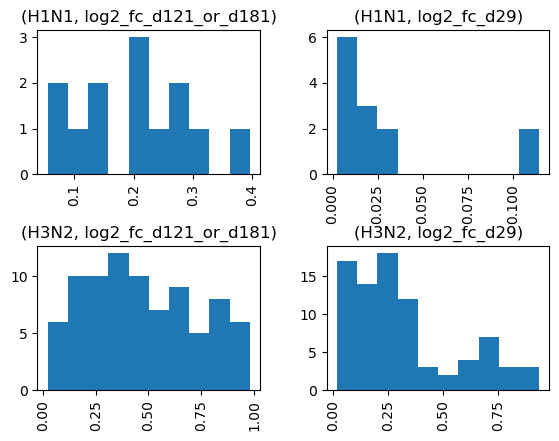


Plots of distributions of Q-values:


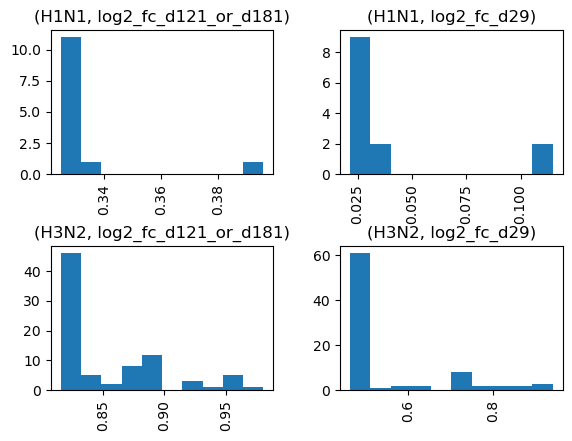


Number of differences that are significant:


n_viruses  n_fdr_significant  \
subtype metric                                               
H1N1    log2_fc_d121_or_d181         13                  0   
        log2_fc_d29                  13                 11   
H3N2    log2_fc_d121_or_d181         83                  0   
        log2_fc_d29                  83                  0   

                              uncorrected_pval_significant  
subtype metric                                              
H1N1    log2_fc_d121_or_d181                             0  
        log2_fc_d29                                     11  
H3N2    log2_fc_d121_or_d181                             4  
        log2_fc_d29                                      6


Viruses with FDR significant differences:


p  median_diff  \
subtype metric      virus                                                      
H1N1    log2_fc_d29 A/Victoria/1389/2023_H1N1          0.002481    -1.389009   
                    A/Netherlands/1739/2023_H1N1       0.003327    -1.317769   
                    A/Wisconsin/588/2019_H1N1          0.006112    -1.607127   
                    A/Wisconsin/67/2022_H1N1           0.007077    -1.374360   
                    A/Norway/7787/2023_H1N1            0.010846    -1.167126   
                    A/Pennsylvania/51/2023_H1N1        0.012451    -1.126399   
                    A/Jeonbuk/1544/2023_H1N1           0.016304    -1.131409   
                    A/Victoria/4897/2022_IVR-238_H1N1  0.016304    -1.381151   
                    A/Arizona/IVYG43Q65T3/2023_H1N1    0.021167    -1.449163   
                    A/California/07/2009_H1N1          0.030818    -1.460514   
                    A/Hawaii/70/2019_H1N1              0.030818    -1.169666   

                                                       fdr_significant  \
subtype metric      virus                                                
H1N1    log2_fc_d29 A/Victoria/1389/2023_H1N1                     True   
                    A/Netherlands/1739/2023_H1N1                  True   
                    A/Wisconsin/588/2019_H1N1                     True   
                    A/Wisconsin/67/2022_H1N1                      True   
                    A/Norway/7787/2023_H1N1                       True   
                    A/Pennsylvania/51/2023_H1N1                   True   
                    A/Jeonbuk/1544/2023_H1N1                      True   
                    A/Victoria/4897/2022_IVR-238_H1N1             True   
                    A/Arizona/IVYG43Q65T3/2023_H1N1               True   
                    A/California/07/2009_H1N1                     True   
                    A/Hawaii/70/2019_H1N1                         True   

                                                          fdr_q  
subtype metric      virus                                        
H1N1    log2_fc_d29 A/Victoria/1389/2023_H1N1          0.021622  
                    A/Netherlands/1739/2023_H1N1       0.021622  
                    A/Wisconsin/588/2019_H1N1          0.023000  
                    A/Wisconsin/67/2022_H1N1           0.023000  
                    A/Norway/7787/2023_H1N1            0.026494  
                    A/Pennsylvania/51/2023_H1N1        0.026494  
                    A/Jeonbuk/1544/2023_H1N1           0.026494  
                    A/Victoria/4897/2022_IVR-238_H1N1  0.026494  
                    A/Arizona/IVYG43Q65T3/2023_H1N1    0.030575  
                    A/California/07/2009_H1N1          0.036421  
                    A/Hawaii/70/2019_H1N1              0.036421


Viruses with uncorrected P-value significant differences:


p  \
subtype metric               virus                                            
H1N1    log2_fc_d29          A/Victoria/1389/2023_H1N1             0.002481   
                             A/Netherlands/1739/2023_H1N1          0.003327   
                             A/Wisconsin/588/2019_H1N1             0.006112   
                             A/Wisconsin/67/2022_H1N1              0.007077   
                             A/Norway/7787/2023_H1N1               0.010846   
                             A/Pennsylvania/51/2023_H1N1           0.012451   
                             A/Jeonbuk/1544/2023_H1N1              0.016304   
                             A/Victoria/4897/2022_IVR-238_H1N1     0.016304   
                             A/Arizona/IVYG43Q65T3/2023_H1N1       0.021167   
                             A/California/07/2009_H1N1             0.030818   
                             A/Hawaii/70/2019_H1N1                 0.030818   
H3N2    log2_fc_d121_or_d181 A/Texas/50/2012_H3N2                  0.022089   
                             A/HongKong/4801/2014_H3N2             0.039173   
                             A/Singapore/INFIMH-16-0019/2016_H3N2  0.040239   
                             A/HongKong/2671/2019_H3N2             0.043898   
        log2_fc_d29          A/HongKong/2671/2019_H3N2             0.016238   
                             A/Texas/50/2012_H3N2                  0.019270   
                             A/HongKong/4801/2014_H3N2             0.034782   
                             A/Singapore/INFIMH-16-0019/2016_H3N2  0.040239   
                             A/Bangkok/P3755/2023_H3N2             0.044027   
                             A/Cambodia/e0826360/2020egg_H3N2      0.049378   

                                                                   median_diff  \
subtype metric               virus                                               
H1N1    log2_fc_d29          A/Victoria/1389/2023_H1N1               -1.389009   
                             A/Netherlands/1739/2023_H1N1            -1.317769   
                             A/Wisconsin/588/2019_H1N1               -1.607127   
                             A/Wisconsin/67/2022_H1N1                -1.374360   
                             A/Norway/7787/2023_H1N1                 -1.167126   
                             A/Pennsylvania/51/2023_H1N1             -1.126399   
                             A/Jeonbuk/1544/2023_H1N1                -1.131409   
                             A/Victoria/4897/2022_IVR-238_H1N1       -1.381151   
                             A/Arizona/IVYG43Q65T3/2023_H1N1         -1.449163   
                             A/California/07/2009_H1N1               -1.460514   
                             A/Hawaii/70/2019_H1N1                   -1.169666   
H3N2    log2_fc_d121_or_d181 A/Texas/50/2012_H3N2                    -0.911326   
                             A/HongKong/4801/2014_H3N2               -0.567070   
                             A/Singapore/INFIMH-16-0019/2016_H3N2    -1.823628   
                             A/HongKong/2671/2019_H3N2               -1.049518   
        log2_fc_d29          A/HongKong/2671/2019_H3N2               -1.569414   
                             A/Texas/50/2012_H3N2                    -0.955974   
                             A/HongKong/4801/2014_H3N2               -1.217549   
                             A/Singapore/INFIMH-16-0019/2016_H3N2    -1.475562   
                             A/Bangkok/P3755/2023_H3N2               -0.660616   
                             A/Cambodia/e0826360/2020egg_H3N2        -0.906428   

                                                                   fdr_significant  \
subtype metric               virus                                                   
H1N1    log2_fc_d29          A/Victoria/1389/2023_H1N1                        True   
                             A/Netherlands/1739/2023_H1N1                     True   
                         

Saving to statsfile='../results/stats_on_significance.csv'


In [16]:
# Mann Whitney U two-sided test
records = []

sig_threshold = 0.05  # threshold for significance

for (titer, titer_df), metric in itertools.product(
    pivot_titers.groupby('virus'), ("log2_fc_d29", "log2_fc_d121_or_d181")
):
    groupA = titer_df[titer_df['vaccine'] == 'Fluarix (n=14)'][metric].dropna()
    groupB = titer_df[titer_df['vaccine'] == 'mRNA-1010 (n=13)'][metric].dropna()

    if len(groupA) > 0 and len(groupB) > 0:
        # Mann-Whitney U Test (two-sided)
        stat, p = mannwhitneyu(groupA, groupB, alternative='two-sided')
        records.append((titer, titer.split("_")[-1], metric, p, groupA.median() - groupB.median()))
    else:
        # Not enough data — skip
        raise ValueError(f"No data for {titer=}")

pval_df = pd.DataFrame(records, columns=["virus", "subtype", "metric", "p", "median_diff"])

print("Plots of distributions of P-values:")
pval_df.hist("p", by=["subtype", "metric"])
plt.show()
plt.close()

# get FDR significant at threshold
pval_df["fdr_significant"] = pval_df.groupby(["metric", "subtype"])["p"].transform(
    lambda p: statsmodels.stats.multitest.multipletests(p, alpha=sig_threshold, method="fdr_bh")[0]
)
pval_df["fdr_q"] = pval_df.groupby(["metric", "subtype"])["p"].transform(
    lambda p: statsmodels.stats.multitest.multipletests(p, alpha=sig_threshold, method="fdr_bh")[1]
)

print("\nPlots of distributions of Q-values:")
pval_df.hist("fdr_q", by=["subtype", "metric"])
plt.show()
plt.close()

print("\nNumber of differences that are significant:")
display(
    pval_df
    .groupby(["subtype", "metric"])
    .aggregate(
        n_viruses=pd.NamedAgg("virus", "count"),
        n_fdr_significant=pd.NamedAgg("fdr_significant", "sum"),
        uncorrected_pval_significant=pd.NamedAgg("p", lambda p: (p < sig_threshold).sum()),
    )
)

print("\nViruses with FDR significant differences:")
display(
    pval_df
    .query("fdr_significant")
    .sort_values(["subtype", "metric", "p"])
    .set_index(["subtype", "metric", "virus"])
)

print("\nViruses with uncorrected P-value significant differences:")
display(
    pval_df
    .query("p < @sig_threshold")
    .sort_values(["subtype", "metric", "p"])
    .set_index(["subtype", "metric", "virus"])
)

statsfile = os.path.join(resultsdir, "stats_on_significance.csv")
print(f"Saving to {statsfile=}")
pval_df.to_csv(statsfile, index=False)

## Distributions

In [17]:
single_virus_df = pivot_titers.query('virus == "A/AbuDhabi/6753/2023_H3N2"').reset_index(drop=True)

for vax in single_virus_df.vaccine.unique():
    print(vax)

    print('there are this many participants', (len(single_virus_df.query(f'vaccine == "{vax}"'))))
    print('this many have day 121', (len(single_virus_df.query(f'vaccine == "{vax}"')[['d121']].dropna())))

Fluarix (n=14)
there are this many participants 14
this many have day 121 4
mRNA-1010 (n=13)
there are this many participants 13
this many have day 121 2


In [18]:
pivot_titers.query('subtype == "H1N1"')

alt.Chart(pivot_titers.query('subtype == "H1N1"')).mark_bar().encode(
    alt.X('d0:Q', bin=True),  # bin=True automatically chooses bin size
    y='count()'
).properties(
    title='Distribution of values'
)

alt.Chart(...)

## Show with lines

In [19]:
def plot_FC_vaccination_cohorts_with_lines(data, y_axis, _range = [0, 1], title=None):
    # Make plot with all individuals and median dots
    color_scheme = alt.Color('vaccine', sort=['Fluarix (n=15)']).scale(range=color_palette)
    titer_range = _range
    titleFontSize=18
    labelFontSize=18
    lineOpacity = 0.2
    lineSize = 2.8
    markerOpacity = 0.8
    markerSize = 160

    band = (alt.Chart(data)
            .mark_errorband(extent='iqr', opacity=0.4)
            .encode(alt.X('virus', axis = alt.Axis(grid=False, titleFontSize=titleFontSize, labelFontSize=labelFontSize,
                                          title = None,labelLimit = 1000, labelAlign = 'right'),             
                          sort = virus_order),
                    alt.Y(f'{y_axis}', 
                          scale =alt.Scale(domain=_range, nice=False), 
                          axis=alt.Axis(grid=False, titleFontSize=titleFontSize, labelFontSize=labelFontSize, title=["log2FC titer", "from pre-vaccination"])),
                color = color_scheme,)
           ) 


    line = (alt.Chart(data)
            .mark_line(size = lineSize, point = False, opacity = lineOpacity)
            .encode(
                alt.X('virus', axis = alt.Axis(grid=False, titleFontSize=titleFontSize, labelFontSize=labelFontSize,
                                          title = None,labelLimit = 1000, labelAlign = 'right'),             
                          sort = virus_order),
                alt.Y(f'{y_axis}', 
                          scale =alt.Scale(domain=_range, nice=False), 
                          axis=alt.Axis(grid=False, titleFontSize=titleFontSize, labelFontSize=labelFontSize, title=["log2FC titer", "from pre-vaccination"])),
                detail = 'participant',
                color = color_scheme,
                # order = 'virus_order'
            )
           )
    
    points = (alt.Chart(data)
              .mark_point(size = markerSize, stroke = 'black', strokeWidth = 2.2, filled=True,  opacity=markerOpacity)
              .encode(alt.X('virus', sort = virus_order),
                      alt.Y(f'median({y_axis})'),
                      color = color_scheme,))
        
    layered = (alt.layer(band, line, points)
               .properties(title=title)
               .configure_header(title=None,
                                  labelFontSize=labelFontSize,labelFontWeight='bold',
                                  labelOrient='right', 
                                )
               .configure_title(align='center', anchor='middle', fontSize=titleFontSize, fontWeight='bold')
           .configure_legend(symbolSize=markerSize, symbolOpacity=markerOpacity, symbolStrokeWidth=2.2, symbolStrokeColor='black', 
                             titleFontSize=titleFontSize, labelFontSize = labelFontSize,
                            strokeColor='gray',padding=10,cornerRadius=10,
                            labelLimit = 1000 # Let legend labels be as long as they want
                            )
    )

    return layered

In [20]:
for subtype in titers.subtype.unique():
    data = pivot_titers[pivot_titers['subtype'].isin([subtype])]

    plot = plot_FC_vaccination_cohorts_with_lines(data, 
                                           y_axis = 'log2_fc_d29',
                                           _range=[-0.6, 6], title = f'Log2 FC day 29 titers to {subtype} 2023-2024 circulating strains and recent vaccine strains')
    # Save final plot
    outfile = os.path.join(resultsdir, f'{subtype}_day29_pre-post_fold-change_LINES.pdf')
    plot.save(outfile, dpi = 600)


In [21]:
IFrame(os.path.join(resultsdir, 'H3N2_day29_pre-post_fold-change_LINES.pdf'), width=700, height=500)

In [22]:
IFrame(os.path.join(resultsdir, 'H1N1_day29_pre-post_fold-change_LINES.pdf'), width=700, height=500)

In [23]:
if 'd121' in pivot_titers.columns:
    y_axis = 'log2_fc_d121_or_d181'
else:
    y_axis = 'log2_fc_d181'

for subtype in titers.subtype.unique():
    data = pivot_titers[pivot_titers['subtype'].isin([subtype])]

    plot = plot_FC_vaccination_cohorts_with_lines(data, 
                                           y_axis = y_axis,
                                           _range=[-1.5, 4.5], title = f'Log2 FC day 121/181 titers to {subtype} 2023-2024 circulating strains and recent vaccine strains')
    # Save final plot
    outfile = os.path.join(resultsdir, f'{subtype}_day121-181_pre-post_fold-change_LINES.pdf')
    plot.save(outfile, dpi = 600)


In [24]:
IFrame(os.path.join(resultsdir, 'H3N2_day121-181_pre-post_fold-change_LINES.pdf'), width=700, height=500)

In [25]:
IFrame(os.path.join(resultsdir, 'H1N1_day121-181_pre-post_fold-change_LINES.pdf'), width=700, height=500)